In [76]:
#importing required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Defining the differentiation functon that are being used in this assignment

In [77]:
#Central Difference method
def central_difference_method(x, y):
    derivative = []
    x_loc = []

    for i in range(1, len(x)-1):
        dy = (y[i+1] - y[i-1])/(x[i+1] - x[i-1])
        derivative.append(dy)
        x_loc.append(x[i])

    return np.array(derivative), np.array(x_loc)


#Forward Difference mehtod
def forward_difference_method(x,y):
    gradient = []
    x_loc = []

    for i in range(len(x)-1):
        g = (y[i+1] - y[i])/(x[i+1] - x[i])
        gradient.append(g)
        x_loc.append((x[i] + x[i+1])/2)

    return np.array(gradient), np.array(x_loc)


#Backward difference method
def backward_difference_method(x,y):
    gradient = []
    x_loc = []

    for i in range(1, len(x)):
      g = (y[i] - y[i-1])/(x[i] - x[i-1])
      gradient.append(g)
      x_loc.append((x[i] + x[i-1])/2)

    return np.array(gradient), np.array(x_loc)

#Defining the Integration Methods

In [78]:
#trapezoidal method

def trapezoidal_method(x, y):
  int_value = 0.0
  for i in range(len(x) - 1):
    int_value +=  (x[i+1] - x[i]) * (y[i] + y[i+1])/2
  return int_value

#simpson 1/3rd Rule Formula

def simpson_1_3_rule(x, y):

    n = len(x)

    if (n-1) % 2 != 0:
        raise ValueError("Simpson 1/3 rule requires even number of intervals")

    h = x[1] - x[0]

    odd_term = 0.0
    even_term = 0.0

    for i in range(1, n-1, 2):
        odd_term += y[i]

    for i in range(2, n-1, 2):
        even_term += y[i]

    int_value = (h/3) * (y[0] + y[-1] + 4*odd_term + 2*even_term)

    return int_value


#simpson 3/8th rule

def simpson_3_8_rule(x, y):

    n = len(x)

    if (n-1) % 3 != 0:
        raise ValueError("Simpson 3/8 rule requires intervals multiple of 3")

    h = x[1] - x[0]

    multiple_of_3 = 0.0
    other_term = 0.0

    for i in range(1, n-1):
        if i % 3 == 0:
            multiple_of_3 += y[i]
        else:
            other_term += y[i]

    int_value = (3*h/8) * (y[0] + y[-1] + 3*other_term + 2*multiple_of_3)

    return int_value

## Defining the function for the calculation of arc length, unit normal vector and total flux



In [79]:
#arc length
def arc_length(x, y):
    dydx, x_loc = central_difference_method(x, y)
    dx = x[1] - x[0]
    ds = dx * np.sqrt(1 + dydx**2)
    return ds, x_loc

#unit normal vector
def unit_normal_vector(dydx):
    denom = np.sqrt(1 + dydx**2)
    nx = -dydx / denom
    ny = 1 / denom
    return nx, ny

## Part - 1 : Concentration as a spatial field

The solute concentration $c(x)$ is measured experimentally along a line parallel to the interface. Measurements are taken at uniformly spaced discrete positions.

| Index | $x$ (cm) | $c(x)$ (arb. units) |
|------|------|------|
| 1 | 0.0 | 1.00 |
| 2 | 0.5 | 0.94 |
| 3 | 1.0 | 0.88 |
| 4 | 1.5 | 0.81 |
| 5 | 2.0 | 0.74 |
| 6 | 2.5 | 0.69 |
| 7 | 3.0 | 0.63 |
| 8 | 3.5 | 0.59 |
| 9 | 4.0 | 0.55 |
| 10 | 4.5 | 0.52 |
| 11 | 5.0 | 0.50 |

**Table 1:** Concentration $c(x)$ as a function of position $x$.


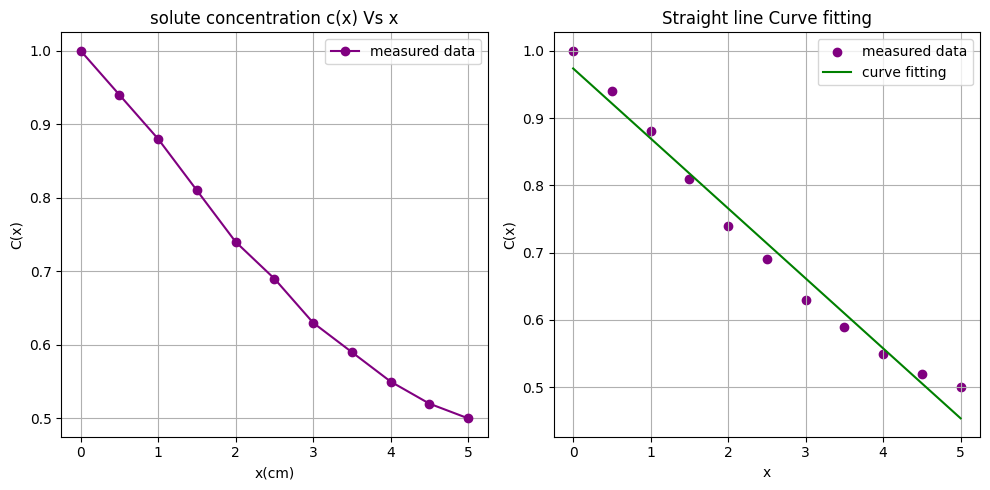

In [80]:
#Mesurements
x = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])  #(cm)
cx = np.array([1.00, 0.94, 0.88, 0.81, 0.74, 0.69, 0.63, 0.59, 0.55, 0.52, 0.50]) #(arb. units)

#curve fitting
def straight_line(x, m, c):
  return m*x + c

popt, pcov = curve_fit(straight_line, x, cx)
#intercepts
m, c = popt
#error in parameters
sigma_m, sigma_c = np.sqrt(np.diag(pcov))

#fitted line
cx_fit = straight_line(x, m, c)

#Graphs plot
fig, ax = plt.subplots(1, 2, figsize=(10,5))

#graph for solute concentration c(x) vs x
ax[0].plot(x, cx, label="measured data", marker="o", color="purple")
ax[0].set_title("solute concentration c(x) Vs x")
ax[0].set_xlabel("x(cm)")
ax[0].set_ylabel("C(x)")
ax[0].legend()
ax[0].grid(True)

#curve fitting(straight_line)
ax[1].scatter(x, cx, label="measured data", c="purple")
ax[1].plot(x, cx_fit, label="curve fitting", color='green')
ax[1].set_title("Straight line Curve fitting")
ax[1].set_xlabel("x")
ax[1].set_ylabel("C(x)")
ax[1].legend()
ax[1].grid(True)

#tight layout
plt.tight_layout()
plt.show()


In [81]:

print("Results of Straight line fit")
print(f"Slope: {m}")
print(f"Intercept: {c}")

#error in slope and intercept
print(f'error in slope: {sigma_m}')
print(f'error in intercept: {sigma_c}')

Results of Straight line fit
Slope: -0.10399999985648277
Intercept: 0.9736363632775705
error in slope: 0.00501091551641389
error in intercept: 0.014822487967230848


#PART 2

Diffusive transport is governed by Fick’s law:

$$J(x) = -D \dfrac{dc}{dx}$$

where $J(x)$ is the diffusive flux along the $x$ direction and $D$ = 0.10$cm^2/s$

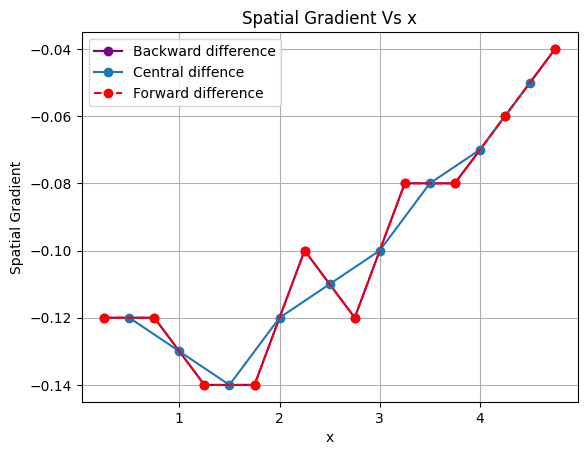

Backward difference method
Spatial Gradient: [-0.12 -0.12 -0.14 -0.14 -0.1  -0.12 -0.08 -0.08 -0.06 -0.04]
Spatial Gradient location: [0.25 0.75 1.25 1.75 2.25 2.75 3.25 3.75 4.25 4.75]

Center difference method
Spatial Gradient: [-0.12 -0.13 -0.14 -0.12 -0.11 -0.1  -0.08 -0.07 -0.05]
Spatial Gradient location: [0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5]

Center difference method
Spatial Gradient: [-0.12 -0.12 -0.14 -0.14 -0.1  -0.12 -0.08 -0.08 -0.06 -0.04]
Spatial Gradient location: [0.25 0.75 1.25 1.75 2.25 2.75 3.25 3.75 4.25 4.75]



In [82]:
#calculating gradient usign backward, central, forward difference method
gradient_bdm, x_loc_bdm = backward_difference_method(x, cx)
gradient_cdm, x_loc_cdm = central_difference_method(x, cx)
gradient_fdm, x_loc_fdm = forward_difference_method(x, cx)


plt.plot(x_loc_bdm, gradient_bdm, color="purple", label="Backward difference", marker= "o")
plt.plot(x_loc_cdm, gradient_cdm, label="Central diffence", marker= "o")
plt.plot(x_loc_fdm, gradient_fdm, label="Forward difference", linestyle="--", marker= "o", color="r")

plt.title("Spatial Gradient Vs x")
plt.xlabel("x")
plt.ylabel("Spatial Gradient")
plt.legend()
plt.grid(True)
plt.show()


#print the results

#backward difference method
print("Backward difference method")
print(f"Spatial Gradient: {gradient_bdm}")
print(f"Spatial Gradient location: {x_loc_bdm}\n")

#center difference method
print("Center difference method")
print(f"Spatial Gradient: {gradient_cdm}")
print(f"Spatial Gradient location: {x_loc_cdm}\n")

#Forward difference method
print("Center difference method")
print(f"Spatial Gradient: {gradient_fdm}")
print(f"Spatial Gradient location: {x_loc_fdm}\n")



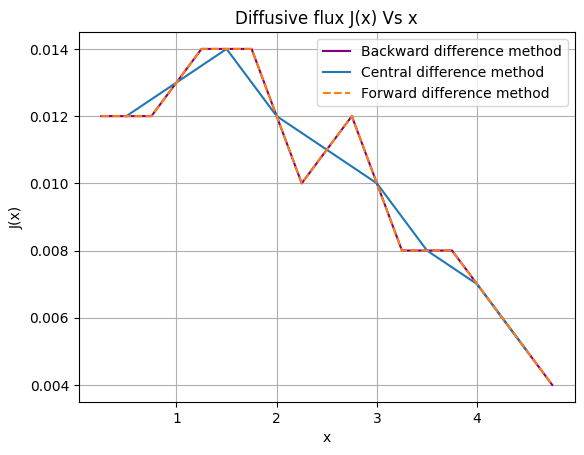

In [83]:
#stepsize
h = 0.5

#value of Diffusion coeffiecient
D = 0.10 #cm^2/s

#Local diffusive flux
def J(D, cx_dx):
  return -D*cx_dx

Jx_backward = J(D, gradient_bdm)
Jx_central = J(D, gradient_cdm)
Jx_forward = J(D, gradient_fdm)


#plot for diffusive flux
plt.plot(x_loc_bdm,Jx_backward, label="Backward difference method", color="purple")
plt.plot(x_loc_cdm,Jx_central, label="Central difference method")
plt.plot(x_loc_fdm,Jx_forward, label="Forward difference method", linestyle="--")
plt.title("Diffusive flux J(x) Vs x")
plt.xlabel("x")
plt.ylabel("J(x)")
plt.legend(loc="best")
plt.grid(True)
plt.show()


In [84]:
#print the results

print(f"Backward difference method")
print(f"Local diffusive flux: {Jx_backward}\n")

print(f"Central difference method")
print(f"Local diffusive flux: {Jx_central}\n")

print(f"Forward difference method")
print(f"Local diffusive flux: {Jx_forward}\n")

Backward difference method
Local diffusive flux: [0.012 0.012 0.014 0.014 0.01  0.012 0.008 0.008 0.006 0.004]

Central difference method
Local diffusive flux: [0.012 0.013 0.014 0.012 0.011 0.01  0.008 0.007 0.005]

Forward difference method
Local diffusive flux: [0.012 0.012 0.014 0.014 0.01  0.012 0.008 0.008 0.006 0.004]



## Part - 3 : Integrated quantities and transport

While flux evaluated before is a local quantity, let us now focus on the global transport.

For the same, you need to:

1. Compute the **total solute content** along the measured region

$$
M = \int c(x)\,dx
$$

2. Compute the **net diffusive transport** across the region

$$
\Phi_x = \int J(x)\,dx
$$

In [85]:
#Integration using trapazoidal method and Simpson rule

#Compute total solute content(M)
M_trapz = trapezoidal_method(x,cx)
M_simpson_1_3 = simpson_1_3_rule(x,cx)
#M_simpson_3_8 = simpson_3_8_rule(x,cx)

#net diffusive transport for the Jx calculated by CDM
phi_x_trapz_cdm =  trapezoidal_method(x_loc_cdm, Jx_central )
phi_x_simpson_1_3 = simpson_1_3_rule(x_loc_cdm, Jx_central)

#net diffusive transport for the Jx calculated by BDM/FDM
phi_x_trapz_bdm =  trapezoidal_method(x_loc_bdm, Jx_backward)
phi_x_simpson_3_8 = simpson_3_8_rule(x_loc_bdm, Jx_backward)

#print results
print("total solute content(M):")
print(f"M_trapz: {M_trapz}")
print(f"M_simpson_1_3: {M_simpson_1_3} \n")

print("net diffusive transport for the Jx calculated by CDM:")
print(f"phi_x_trapz: {phi_x_trapz_cdm}")
print(f"phi_x_simpson_1_3: {phi_x_simpson_1_3}\n")

print("net diffusive transport for the Jx calculated by BDM/FDM:")
print(f"phi_x_trapz: {phi_x_trapz_bdm}")
print(f"phi_x_simpson_3_8: {phi_x_simpson_3_8}")

total solute content(M):
M_trapz: 3.5500000000000003
M_simpson_1_3: 3.5499999999999994 

net diffusive transport for the Jx calculated by CDM:
phi_x_trapz: 0.041749999999999995
phi_x_simpson_1_3: 0.041833333333333333

net diffusive transport for the Jx calculated by BDM/FDM:
phi_x_trapz: 0.04599999999999999
phi_x_simpson_3_8: 0.04612499999999999


#PART 4: Geometry of the interface

If the interface has a shape described by the curve $y = h(x)$

| Index | x (cm) | c(x) (arb. units) | h(x) (cm) |
|------|------|------------------|---------|
| 1 | 0.0 | 1.00 | 0.00 |
| 2 | 0.5 | 0.94 | 0.08 |
| 3 | 1.0 | 0.88 | 0.15 |
| 4 | 1.5 | 0.81 | 0.21 |
| 5 | 2.0 | 0.74 | 0.25 |
| 6 | 2.5 | 0.69 | 0.26 |
| 7 | 3.0 | 0.63 | 0.25 |
| 8 | 3.5 | 0.59 | 0.21 |
| 9 | 4.0 | 0.55 | 0.15 |
| 10 | 4.5 | 0.52 | 0.08 |
| 11 | 5.0 | 0.50 | 0.00 |

**Table 2:** Interface shape dataset


From this data, evaluate:

1. The slope  

$$
\frac{dh}{dx}
$$

2. Arc length element  

$$
ds = \sqrt{1 + \left(\frac{dh}{dx}\right)^2}\, dx
$$

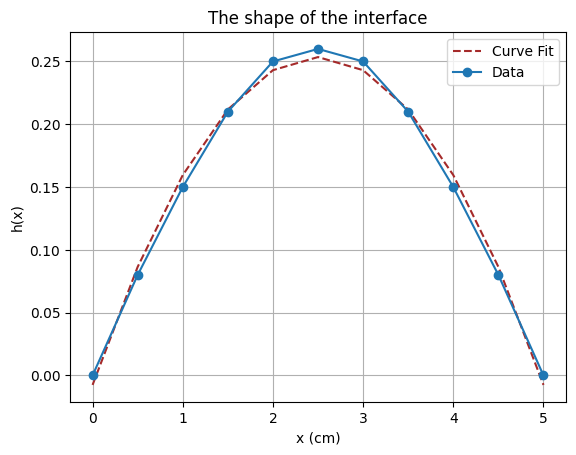

In [86]:
#interface geometry measurement

hx = np.array([0, 0.08, 0.15, 0.21, 0.25, 0.26, 0.25, 0.21,  0.15, 0.08, 0])


def quadratic(x, a, b, c):
    return a*x**2 + b*x + c

popt, pcov = curve_fit(quadratic, x, hx)

# intercepts
a, b, c = popt
# curve fitting
plt.plot(x, quadratic(x, a, b, c), label="Curve Fit", color='brown', linestyle="--")
# shape of the interface
plt.plot(x, hx, marker="o", label="Data")
plt.title("The shape of the interface")
plt.xlabel("x (cm)")
plt.ylabel("h(x)")
plt.grid(True)
plt.legend()
plt.show()

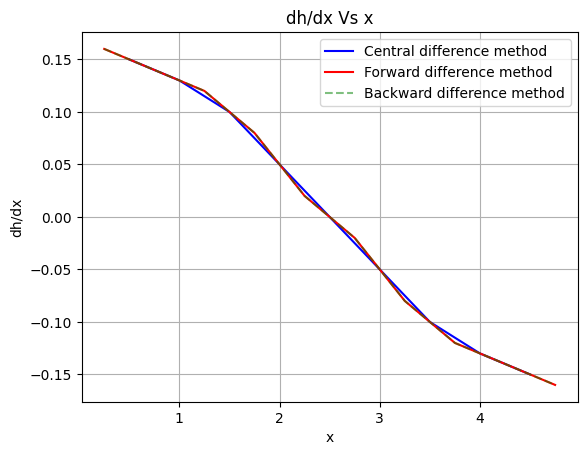


dh/dx(Central difference method): [ 0.15  0.13  0.1   0.05  0.   -0.05 -0.1  -0.13 -0.15]
dh/dx(Forward difference method): [ 0.16  0.14  0.12  0.08  0.02 -0.02 -0.08 -0.12 -0.14 -0.16]
dh/dx(Backward difference method): [ 0.16  0.14  0.12  0.08  0.02 -0.02 -0.08 -0.12 -0.14 -0.16]


In [87]:
#1)
#differentian using central difference method and FDM/BDM
dh_cdm, x_loc_cdm = central_difference_method(x, hx)
dh_fdm, x_loc_fdm = forward_difference_method(x, hx)
dh_bdm, x_loc_bdm = backward_difference_method(x, hx)

#plot
plt.plot(x_loc_cdm, dh_cdm, label="Central difference method", color="blue")
plt.plot(x_loc_fdm, dh_fdm, label="Forward difference method", color="red")
plt.plot(x_loc_bdm, dh_bdm, label="Backward difference method", color="green", linestyle="--", alpha=0.5)
plt.title("dh/dx Vs x")
plt.xlabel("x")
plt.ylabel("dh/dx")
plt.grid(True)
plt.legend()
plt.show()

#print the results
print(f"\ndh/dx(Central difference method): {dh_cdm}")
print(f"dh/dx(Forward difference method): {dh_fdm}")
print(f"dh/dx(Backward difference method): {dh_bdm}")

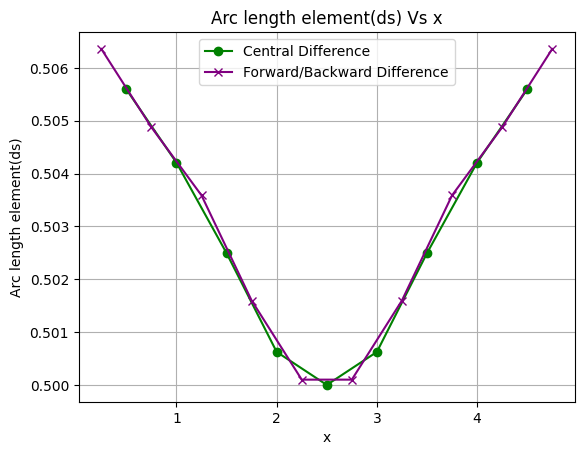

Arc length element(ds)(central difference method): 
 [0.50559371 0.5042073  0.50249378 0.50062461 0.5        0.50062461
 0.50249378 0.5042073  0.50559371]

Arc length element(ds)(forward/backward difference method): 
 [0.50635956 0.50487622 0.50358713 0.50159745 0.50009999 0.50009999
 0.50159745 0.50358713 0.50487622 0.50635956]


In [88]:
#2) Arc length element
dx = h #0.5

#central difference method
dh_square_cdm = np.square(dh_cdm)
ds_cdm = dx*np.sqrt(1 + dh_square_cdm)

#backward/forward difference method
dh_square_bdm = np.square(dh_bdm)
ds_bdm = dx*np.sqrt(1 + dh_square_bdm)

#plots
plt.plot(x_loc_cdm, ds_cdm, label="Central Difference",  color="green", marker="o")
plt.plot(x_loc_bdm, ds_bdm, label="Forward/Backward Difference", color="purple", marker="x")
plt.title("Arc length element(ds) Vs x")
plt.xlabel("x")
plt.ylabel("Arc length element(ds)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

#Print the results
print(f"Arc length element(ds)(central difference method): \n {ds_cdm}\n")
print(f"Arc length element(ds)(forward/backward difference method): \n {ds_bdm}")

In [89]:
#Calculations using central difference method
dh_cdm, x_loc_cdm = central_difference_method(x, hx)
# ds_cdm = dx * np.sqrt(1 + dh_square_cdm)
dxds_cdm = 1/np.sqrt(1 + dh_square_cdm)
dyds_cdm = dh_cdm/np.sqrt(1 + dh_square_cdm)
Jx_central = J(D, gradient_cdm)
#unit normal components
# nx_cdm = -dyds_cdm
# ny_cdm = dxds_cdm
J_dot_n_cdm = Jx_central * (-dh_cdm) #Jx_central * nx_cdm
J_globally_cdm = trapezoidal_method(x_loc_cdm, J_dot_n_cdm)
J_globally_cdm_simpson_1_3 = simpson_1_3_rule(x_loc_cdm, J_dot_n_cdm)

#Calculations using Forward/Backward difference method
dh_bdm, x_loc_bdm= backward_difference_method(x, hx)
# ds_bdm = dx * np.sqrt(1 + dh_square_bdm)
dxds_bdm = 1/np.sqrt(1 + dh_square_bdm)
dyds_bdm = dh_bdm/np.sqrt(1 + dh_square_bdm)
Jx_backward = J(D, gradient_bdm)
#unit normal components
nx_bdm = -dyds_bdm
ny_bdm = dxds_bdm
J_dot_n_bdm = Jx_backward * (-dh_bdm)
J_globally_bdm = trapezoidal_method(x_loc_bdm, J_dot_n_bdm)
J_globally_bdm_simpson_3_8 = simpson_3_8_rule(x_loc_bdm, J_dot_n_bdm)


#print the results
print("Calculation using trapezoidal method")
#The total flux across the interface by central difference method
print(f"The total flux across the interface by central difference method: {J_globally_cdm}")

#The total flux across the interface by backward difference method
print(f"The total flux across the interface by backward difference method: {J_globally_bdm}\n")

print("Calculation using Simpson rule")
print(f"The total flux(CDM): {J_globally_cdm_simpson_1_3}")
print(f"The total flux(BDM): {J_globally_bdm_simpson_3_8}")


Calculation using trapezoidal method
The total flux across the interface by central difference method: -0.0010024999999999995
The total flux across the interface by backward difference method: -0.00132

Calculation using Simpson rule
The total flux(CDM): -0.0009616666666666668
The total flux(BDM): -0.0012749999999999997


The solute is diffusing in the horizontal x direction so the diffusing flux J(x) will be the along x direction. If the interface is flat than normal unit vector of the flat interface will be perpendicular to the diffusive flux vector so the total diffusive flux across the flat interface will be zero.

But when interface is curved shape then unit normal vector of the curve will not be perpendicular to the diffusive flux. So the x component of the unit normal vector will contribute into the total diffusive flux.Therefore , the total flux across the curved interface will not be zero.

In [90]:
#for the flat interface
dhdx = 0
nx, ny = unit_normal_vector(dhdx)
J_flat = J(D, gradient_cdm)
J_dot_n_flat = J_flat * nx   # nx = 0

J_globally_flat = trapezoidal_method(x_loc_cdm, J_dot_n_flat)

print(f"The total flux across the flat interface: {J_globally_flat}")

The total flux across the flat interface: 0.0


In [91]:

# def simpson_1_3_rule(x,y):

#     h = x[1]-x[0]
#     n = len(x)

#     odd_sum = sum(y[1:n-1:2])
#     even_sum = sum(y[2:n-1:2])

#     return (h/3)*(y[0] + y[-1] + 4*odd_sum + 2*even_sum)